In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/anmolkumar/health-insurance-cross-sell-prediction")

Skipping, found downloaded files in "./health-insurance-cross-sell-prediction" (use force=True to force download)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn import tree

In [ ]:
# Load dataset (adjust the file path accordingly)
df = pd.read_csv('/content/health-insurance-cross-sell-prediction/train.csv')

# Display basic information about the dataset
print(df.head())
print(df.info())

   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1    Male   44                1         28.0                   0   
1   2    Male   76                1          3.0                   0   
2   3    Male   47                1         28.0                   0   
3   4    Male   21                1         11.0                   1   
4   5  Female   29                1         41.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0   > 2 Years            Yes         40454.0                  26.0      217   
1    1-2 Year             No         33536.0                  26.0      183   
2   > 2 Years            Yes         38294.0                  26.0       27   
3    < 1 Year             No         28619.0                 152.0      203   
4    < 1 Year             No         27496.0                 152.0       39   

   Response  
0         1  
1         0  
2         1  
3         0  
4         0  
<class '

In [ ]:
df = df.dropna()

In [ ]:
# Convert categorical features to numerical (e.g., Gender, Vehicle_Damage, Vehicle_Age)
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Vehicle_Damage'] = label_encoder.fit_transform(df['Vehicle_Damage'])
df['Vehicle_Age'] = label_encoder.fit_transform(df['Vehicle_Age'])


# Define features (X) and target (y)
X = df.drop(columns=["Response", "id"])  # Remove target variable 'Response' and identifier 'ID'
y = df["Response"]  # Target variable

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- Model 1: Decision Tree Regressor ---
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

In [ ]:
# Evaluate Decision Tree
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)
print(f"Decision Tree - MSE: {dt_mse}, R²: {dt_r2}")

Decision Tree - MSE: 0.17879680407231507, R²: -0.6354125450143766


In [ ]:
# --- Model 2: Random Forest Regressor ---
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [ ]:
# Evaluate Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
print(f"Random Forest - MSE: {rf_mse}, R²: {rf_r2}")

Random Forest - MSE: 0.09485719930941654, R²: 0.1323633856855425


In [ ]:
# --- Visual Comparison of Predicted vs Actual for both models ---
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0, 0.5, 'Predicted')

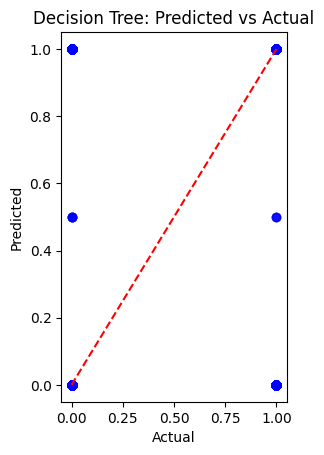

In [ ]:
# Decision Tree predictions
plt.subplot(1, 2, 1)
plt.scatter(y_test, dt_predictions, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Decision Tree: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

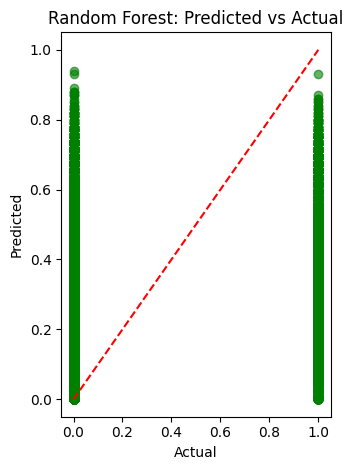

In [ ]:
# Random Forest predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_predictions, color='green', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Random Forest: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# --- Feature Importance Comparison ---
# Decision Tree Feature Importance
dt_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Random Forest Feature Importance
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the feature importance for both models
plt.figure(figsize=(12, 8))


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

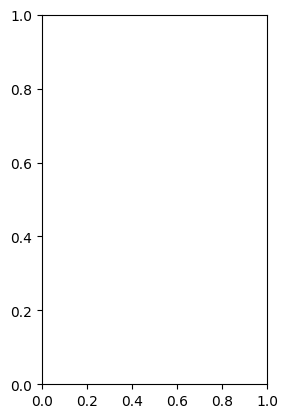

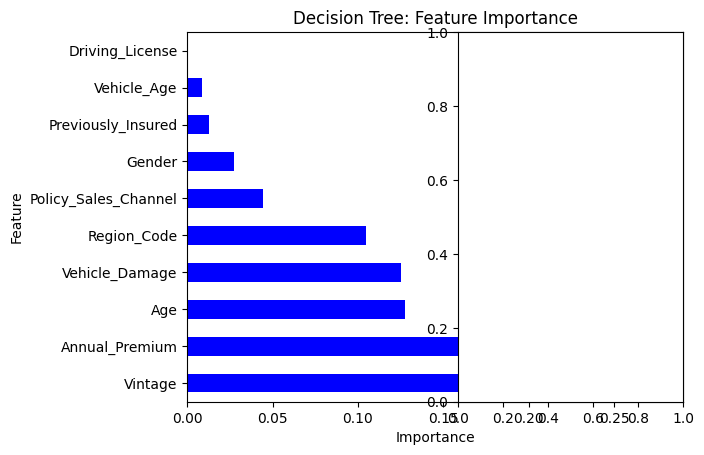

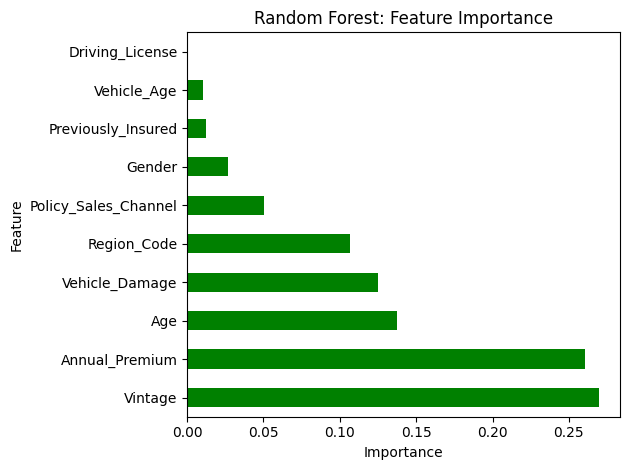

In [ ]:
# Plot Decision Tree feature importance
plt.subplot(1, 2, 1)
dt_feature_importance.plot(kind='barh', x='Feature', y='Importance', legend=False, color='blue')
plt.title("Decision Tree: Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Plot Random Forest feature importance
plt.subplot(1, 2, 2)
rf_feature_importance.plot(kind='barh', x='Feature', y='Importance', legend=False, color='green')
plt.title("Random Forest: Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()